# H2: Distractor Analysis — Do Models Gravitate Toward the Same Wrong Answers?

**Research question:** When VLMs answer incorrectly, do they choose the same distractors? Is there systematic distractor preference that reveals shared failure modes?

## Experimental Setup

- **Models:** Qwen2.5-VL-0.8B, InternVL3.5-1B, InternVL3.5-4B, Gemma3-4B-it
- **Tasks:** Vocab, TROG, EGMA-Math, Mental-Rotation, Matrix-Reasoning, Theory-of-Mind
- **Method:** Reconstruct option-to-content mapping per item using the deterministic seed (`random.Random(item_uid)`), map model predictions back to option content, and compute cross-model distractor agreement.
- **Key metrics:** Cross-model error agreement rate, distractor concentration (entropy), distractor attractiveness profiles

In [1]:
import pandas as pd
import numpy as np
import random
import string
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter, defaultdict
from itertools import combinations
from scipy import stats

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.dpi': 120,
    'figure.facecolor': 'white',
})

REPO = '../../'
ALL_LABELS = list(string.ascii_uppercase)
ABCD = ['A', 'B', 'C', 'D']

## 1. Load Data and Reconstruct Option Mappings

In [2]:
manifest = pd.read_csv(f'{REPO}/data/assets/manifest.csv')

option_map = {}
correct_content = {}

for _, row in manifest.iterrows():
    uid = row['item_uid']
    answer = str(row['answer']).strip()
    if answer == 'nan' or not answer:
        continue
    alts_raw = str(row['response_alternatives']).strip()
    if alts_raw == 'nan' or not alts_raw:
        continue
    alts = [a.strip() for a in alts_raw.split(',')]
    all_options = [answer] + alts

    rng = random.Random(uid)
    rng.shuffle(all_options)

    n = min(len(all_options), len(ALL_LABELS))
    mapping = {ALL_LABELS[i]: all_options[i] for i in range(n)}
    option_map[uid] = mapping
    correct_content[uid] = answer

print(f'Option mappings built for {len(option_map)} items')

Option mappings built for 669 items


In [3]:
frames = []
for model_dir in ['qwen35_0.8B', 'internvl35_1B', 'internvl35_4B']:
    df = pd.read_csv(f'{REPO}/results/item_difficulty/{model_dir}/item_results.csv')
    df['source'] = 'item_difficulty'
    frames.append(df)

for f in ['gemma3_4b-it_json_outputs.csv', 'internvl35_4B_json_outputs.csv', 'qwen35_0.8B_json_outputs.csv']:
    df = pd.read_csv(f'{REPO}/results/json_failures/{f}')
    df['source'] = 'json_failures'
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
raw['priority'] = raw['source'].map({'item_difficulty': 0, 'json_failures': 1})
raw = raw.sort_values('priority').drop_duplicates(subset=['model', 'model_size', 'item_uid'], keep='first')
raw = raw.drop(columns=['priority'])
raw = raw[(raw['parsed'] == 1) & raw['item_uid'].isin(option_map)].copy()
raw['model_label'] = raw['model'] + '_' + raw['model_size']

print(f'Total: {len(raw)} item predictions across {raw["model_label"].nunique()} models')
print(raw.groupby('model_label')[['is_correct']].agg(['count','mean']).round(3))

Total: 2354 item predictions across 4 models
              is_correct       
                   count   mean
model_label                    
gemma3_4b-it         617  0.574
internvl35_1B        502  0.492
internvl35_4B        617  0.739
qwen35_0.8B          618  0.487


In [4]:
def get_predicted_content(row):
    mapping = option_map.get(row['item_uid'], {})
    return mapping.get(str(row['predicted']).strip(), str(row['predicted']))

raw['predicted_content'] = raw.apply(get_predicted_content, axis=1)
raw['correct_content'] = raw['item_uid'].map(correct_content)

errors = raw[raw['is_correct'] == 0].copy()
print(f'Total errors: {len(errors)} across {errors["model_label"].nunique()} models')
print(f'Errors per model:')
print(errors.groupby('model_label').size())

Total errors: 996 across 4 models
Errors per model:
model_label
gemma3_4b-it     263
internvl35_1B    255
internvl35_4B    161
qwen35_0.8B      317
dtype: int64


## 2. Cross-Model Error Agreement

For each pair of items where both models err, do they pick the **same** wrong answer? Chance-level agreement for 4-option items is ~33.3%.

In [5]:
models = sorted(raw['model_label'].unique())
error_sets = {m: set(errors[errors['model_label'] == m]['item_uid']) for m in models}
pred_map = {m: dict(zip(errors[errors['model_label'] == m]['item_uid'],
                        errors[errors['model_label'] == m]['predicted_content']))
            for m in models}

agreement_rows = []
for m1, m2 in combinations(models, 2):
    shared_errors = error_sets[m1] & error_sets[m2]
    if len(shared_errors) < 3:
        continue
    same_distractor = sum(1 for uid in shared_errors
                         if pred_map[m1].get(uid) == pred_map[m2].get(uid))
    n = len(shared_errors)
    agreement_rows.append({
        'Model A': m1, 'Model B': m2,
        'Shared errors': n,
        'Same distractor': same_distractor,
        'Agreement %': round(100 * same_distractor / n, 1) if n > 0 else 0
    })

agreement_df = pd.DataFrame(agreement_rows)
print('Cross-model distractor agreement (when both models err on same item):')
agreement_df

Cross-model distractor agreement (when both models err on same item):


,Model A,Model B,Shared errors,Same distractor,Agreement %
0,gemma3_4b-it,internvl35_1B,112,77,68.8
1,gemma3_4b-it,internvl35_4B,118,72,61.0
2,gemma3_4b-it,qwen35_0.8B,184,118,64.1
3,internvl35_1B,internvl35_4B,77,44,57.1
4,internvl35_1B,qwen35_0.8B,169,125,74.0
5,internvl35_4B,qwen35_0.8B,126,73,57.9


In [6]:
# Per-task cross-model agreement
tasks = sorted(errors['task'].unique())
task_agreement = []

for task in tasks:
    task_errors = errors[errors['task'] == task]
    task_error_sets = {m: set(task_errors[task_errors['model_label'] == m]['item_uid']) for m in models}
    task_pred_map = {
        m: dict(zip(task_errors[task_errors['model_label'] == m]['item_uid'],
                     task_errors[task_errors['model_label'] == m]['predicted_content']))
        for m in models
    }

    for m1, m2 in combinations(models, 2):
        shared = task_error_sets[m1] & task_error_sets[m2]
        if len(shared) < 3:
            continue
        same = sum(1 for uid in shared if task_pred_map[m1].get(uid) == task_pred_map[m2].get(uid))
        task_agreement.append({
            'task': task, 'model_pair': f'{m1} vs {m2}',
            'shared_errors': len(shared),
            'same_distractor': same,
            'agreement_pct': round(100 * same / len(shared), 1)
        })

task_agr_df = pd.DataFrame(task_agreement)
if len(task_agr_df) > 0:
    pivot = task_agr_df.groupby('task')['agreement_pct'].agg(['mean', 'max', 'count']).round(1)
    pivot.columns = ['Mean agreement %', 'Max agreement %', 'N pairs']
    print('Per-task distractor agreement (averaged over model pairs):')
    display(pivot)

Per-task distractor agreement (averaged over model pairs):


,Mean agreement %,Max agreement %,N pairs
task,,,
egma-math,59.5,83.3,6
matrix-reasoning,36.0,47.8,3
mental-rotation,100.0,100.0,6
theory-of-mind,87.7,92.9,3
trog,45.2,72.0,6
vocab,63.6,95.5,6


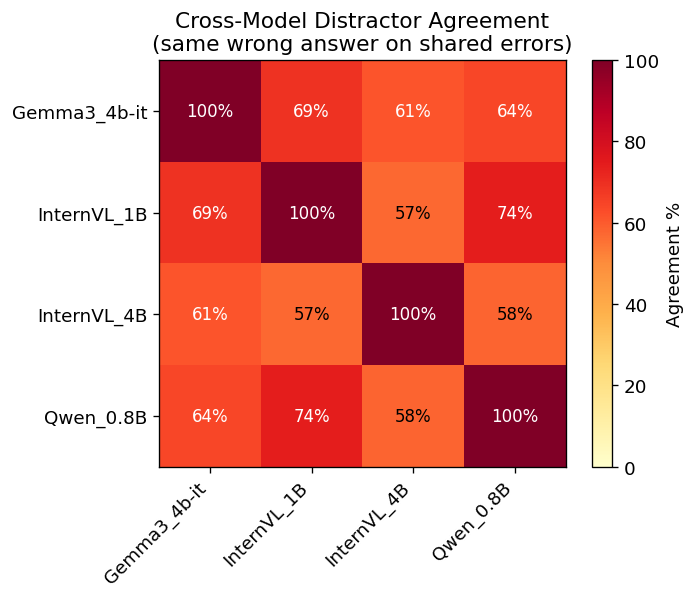

In [7]:
n = len(models)
agr_matrix = np.full((n, n), np.nan)
for _, row in agreement_df.iterrows():
    i = models.index(row['Model A'])
    j = models.index(row['Model B'])
    agr_matrix[i, j] = row['Agreement %']
    agr_matrix[j, i] = row['Agreement %']

np.fill_diagonal(agr_matrix, 100.0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(agr_matrix, cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
short_names = [m.replace('internvl35', 'InternVL').replace('qwen35', 'Qwen').replace('gemma3', 'Gemma3') for m in models]
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_yticklabels(short_names)

for i in range(n):
    for j in range(n):
        if not np.isnan(agr_matrix[i, j]):
            ax.text(j, i, f'{agr_matrix[i,j]:.0f}%', ha='center', va='center', fontsize=10,
                   color='white' if agr_matrix[i,j] > 60 else 'black')

plt.colorbar(im, label='Agreement %')
ax.set_title('Cross-Model Distractor Agreement\n(same wrong answer on shared errors)')
plt.tight_layout()
plt.show()

## 3. Distractor Concentration (Entropy Analysis)

For each item, how concentrated are model errors? Low entropy = models converge on one specific distractor. High entropy = errors are spread randomly.

In [8]:
def compute_entropy(counts):
    total = sum(counts)
    if total == 0:
        return 0
    probs = [c / total for c in counts if c > 0]
    return -sum(p * np.log2(p) for p in probs)

item_error_counts = errors.groupby('item_uid').size()
multi_error_items = item_error_counts[item_error_counts >= 2].index

entropy_rows = []
for uid in multi_error_items:
    item_errors = errors[errors['item_uid'] == uid]
    distractor_counts = Counter(item_errors['predicted_content'])
    n_models_err = len(item_errors)
    n_unique = len(distractor_counts)
    ent = compute_entropy(list(distractor_counts.values()))
    max_ent = np.log2(n_models_err) if n_models_err > 1 else 1

    task = item_errors.iloc[0]['task']
    most_common = distractor_counts.most_common(1)[0]

    entropy_rows.append({
        'item_uid': uid, 'task': task,
        'n_models_err': n_models_err,
        'n_unique_distractors': n_unique,
        'entropy': ent,
        'normalized_entropy': ent / max_ent if max_ent > 0 else 0,
        'top_distractor': most_common[0],
        'top_distractor_count': most_common[1],
    })

entropy_df = pd.DataFrame(entropy_rows)
print(f'Items with 2+ model errors: {len(entropy_df)}')
print(f'Mean normalized entropy: {entropy_df["normalized_entropy"].mean():.3f}')
print(f'Items where ALL models chose same distractor: {(entropy_df["normalized_entropy"] == 0).sum()}')
print(f'\nPer-task entropy:')
display(entropy_df.groupby('task')[['normalized_entropy', 'n_unique_distractors']].mean().round(3))

Items with 2+ model errors: 325
Mean normalized entropy: 0.313
Items where ALL models chose same distractor: 185

Per-task entropy:


,normalized_entropy,n_unique_distractors
task,,
egma-math,0.261,1.388
matrix-reasoning,0.547,1.737
mental-rotation,0.000,1.000
theory-of-mind,0.129,1.150
trog,0.484,1.783
vocab,0.196,1.286


/var/folders/lh/s2wfdq9s0kdffmcbt5q8txg00000gn/T/ipykernel_3737/1204963294.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(task_data, labels=[t.replace('-', '\n') for t in task_labels], patch_artist=True)


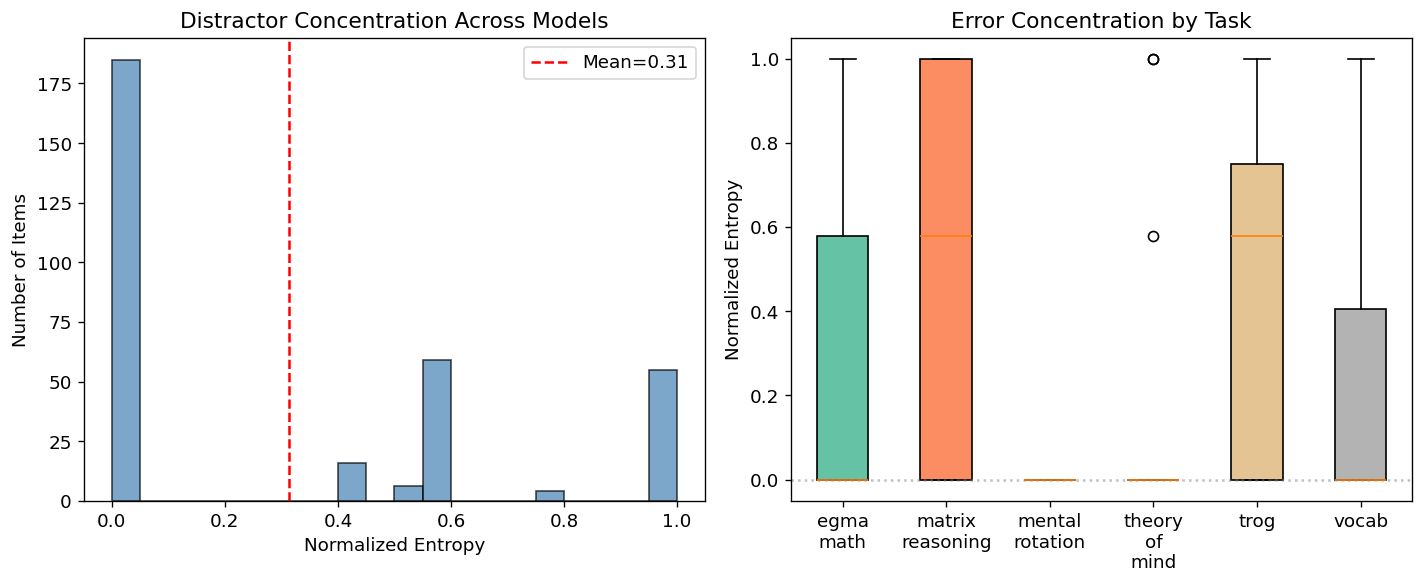

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(entropy_df['normalized_entropy'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(entropy_df['normalized_entropy'].mean(), color='red', ls='--',
           label=f'Mean={entropy_df["normalized_entropy"].mean():.2f}')
ax.set_xlabel('Normalized Entropy')
ax.set_ylabel('Number of Items')
ax.set_title('Distractor Concentration Across Models')
ax.legend()

ax = axes[1]
task_data = [entropy_df[entropy_df['task'] == t]['normalized_entropy'].values
             for t in sorted(entropy_df['task'].unique())]
task_labels = sorted(entropy_df['task'].unique())
bp = ax.boxplot(task_data, labels=[t.replace('-', '\n') for t in task_labels], patch_artist=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(task_labels)))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
ax.set_ylabel('Normalized Entropy')
ax.set_title('Error Concentration by Task')
ax.axhline(0, color='gray', ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Distractor Attractiveness Profiles by Task

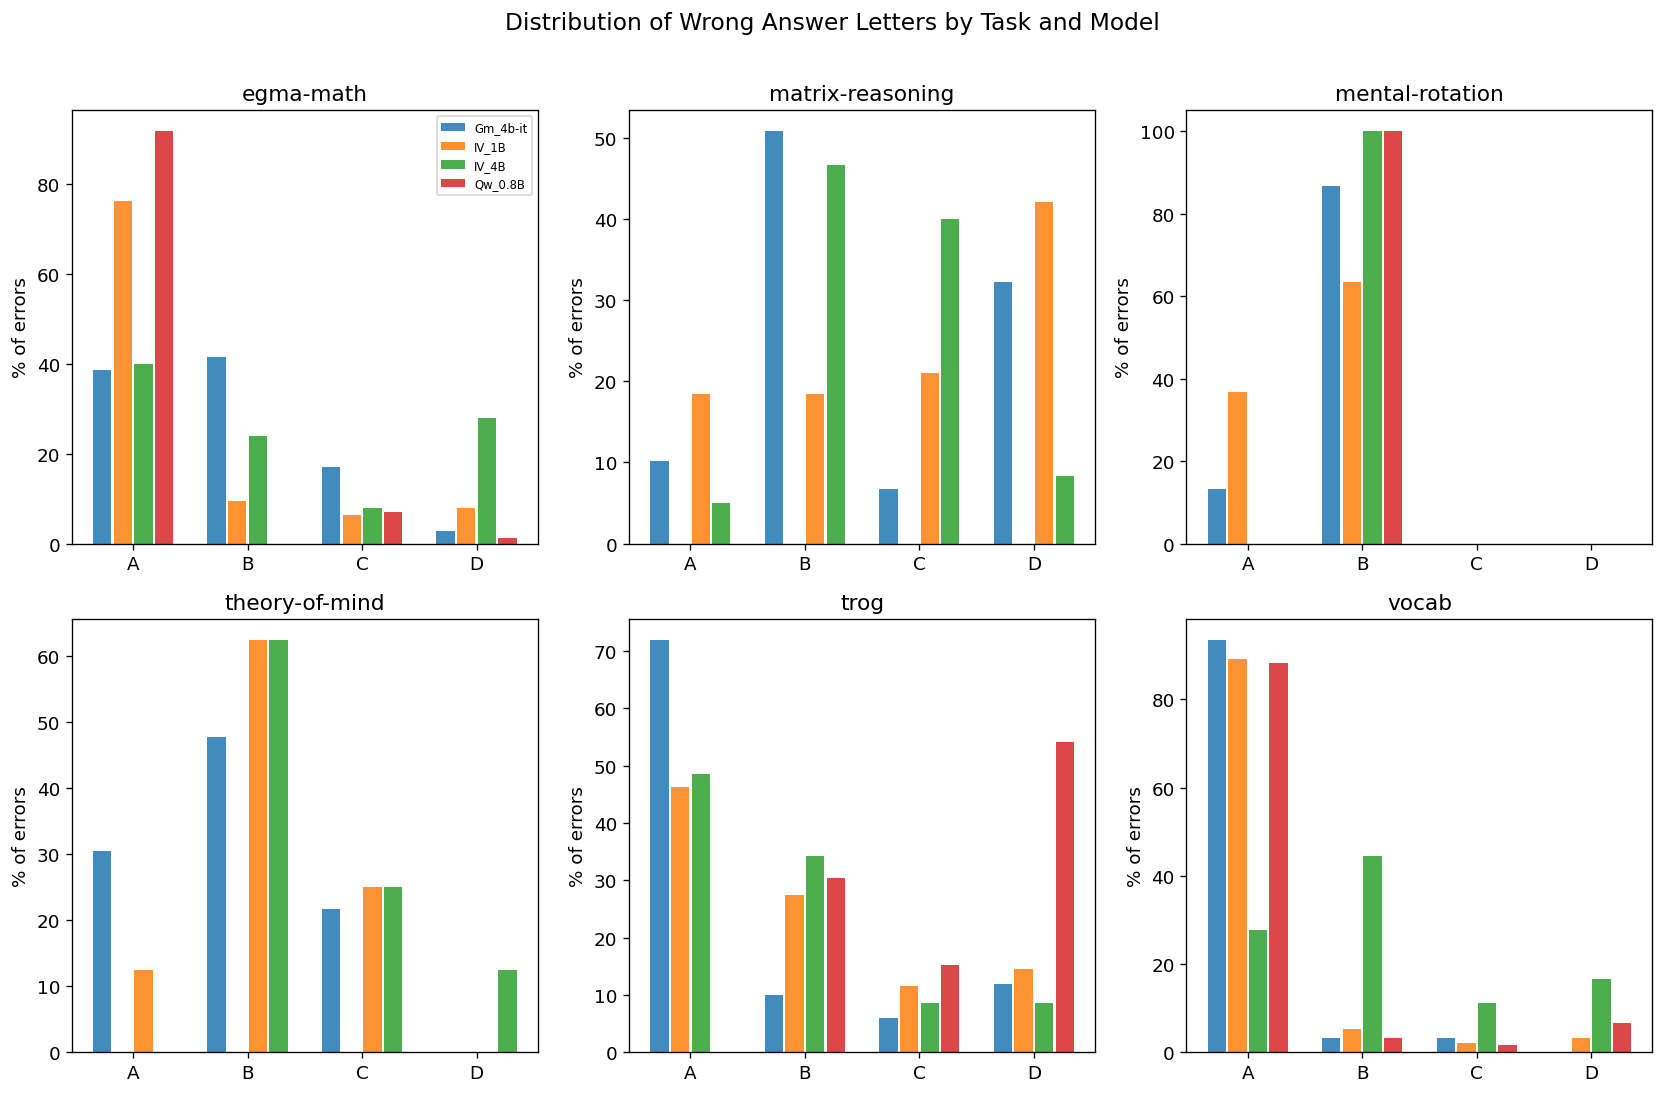

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
tasks = sorted(errors['task'].unique())

for idx, task in enumerate(tasks):
    ax = axes[idx // 3, idx % 3]
    task_err = errors[errors['task'] == task]

    for mi, m in enumerate(models):
        m_err = task_err[task_err['model_label'] == m]
        if len(m_err) == 0:
            continue
        letter_counts = m_err['predicted'].value_counts()
        total = letter_counts.sum()
        pcts = [100 * letter_counts.get(l, 0) / total for l in ABCD]
        short = m.replace('internvl35', 'IV').replace('qwen35', 'Qw').replace('gemma3', 'Gm')
        x = np.arange(len(ABCD)) + mi * 0.18
        ax.bar(x, pcts, width=0.16, label=short, alpha=0.85)

    ax.set_xticks(np.arange(len(ABCD)) + 0.27)
    ax.set_xticklabels(ABCD)
    ax.set_title(task)
    ax.set_ylabel('% of errors')
    if idx == 0:
        ax.legend(fontsize=7)

plt.suptitle('Distribution of Wrong Answer Letters by Task and Model', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Universally Confusing Items

Items where all (or most) models choose the same wrong answer reveal systematic failure modes shared across architectures.

In [11]:
unanimous_errors = entropy_df[
    (entropy_df['normalized_entropy'] == 0) & (entropy_df['n_models_err'] >= 2)
].sort_values('n_models_err', ascending=False).copy()

print(f'Items with 2+ models unanimously choosing the same wrong answer: {len(unanimous_errors)}')
print()
for _, row in unanimous_errors.head(20).iterrows():
    uid = row['item_uid']
    task = row['task']
    correct = correct_content.get(uid, '?')
    chosen = row['top_distractor']
    n = row['n_models_err']
    print(f'  [{task}] {uid}: correct="{correct}", {n} models chose "{chosen}"')

Items with 2+ models unanimously choosing the same wrong answer: 185

  [mental-rotation] mrot_3d_shape_280_bp15-280: correct="bp15-000", 4 models chose "bn15-000"
  [mental-rotation] mrot_2d_rabbit_120_Rn-120: correct="Rn-000-silh", 4 models chose "Rp-000-silh"
  [mental-rotation] mrot_3d_shape_240_bp14-240: correct="bp14-000", 4 models chose "bn14-000"
  [mental-rotation] mrot_3d_shape_240_ap2-240: correct="ap2-000", 4 models chose "an2-000"
  [mental-rotation] mrot_3d_shape_240_an1-240: correct="an1-000", 4 models chose "ap1-000"
  [mental-rotation] mrot_2d_rabbit_240_Rn-240: correct="Rn-000-silh", 4 models chose "Rp-000-silh"
  [mental-rotation] mrot_2d_rabbit_200_Rp-200: correct="Rp-000-silh", 4 models chose "Rn-000-silh"
  [mental-rotation] mrot_2d_rabbit_120_Rp-120: correct="Rp-000-silh", 4 models chose "Rn-000-silh"
  [mental-rotation] mrot_2d_rabbit_040_Rn-040: correct="Rn-000-silh", 4 models chose "Rp-000-silh"
  [egma-math] ns-num-comp-5: correct="5cars", 4 models chose "3ca

In [12]:
summary_rows = []
for task in sorted(entropy_df['task'].unique()):
    t = entropy_df[entropy_df['task'] == task]
    n_total = len(t)
    n_unanimous = (t['normalized_entropy'] == 0).sum()
    summary_rows.append({
        'Task': task,
        'Items with 2+ errors': n_total,
        'Unanimous distractor': n_unanimous,
        'Unanimity rate %': round(100 * n_unanimous / n_total, 1) if n_total > 0 else 0
    })

summary = pd.DataFrame(summary_rows)
print('Distractor unanimity by task:')
display(summary)

Distractor unanimity by task:


,Task,Items with 2+ errors,Unanimous distractor,Unanimity rate %
0,egma-math,85,54,63.5
1,matrix-reasoning,57,17,29.8
2,mental-rotation,31,31,100.0
3,theory-of-mind,20,17,85.0
4,trog,69,21,30.4
5,vocab,63,45,71.4


## 6. Distractor Choice vs. Item Difficulty

Do items with highly concentrated error patterns (low entropy) tend to be harder or easier?

Correlation between error concentration and IRT difficulty:
  Spearman r = -0.010, p = 0.8961 (n=181)
  Interpretation: error concentration is independent of item difficulty


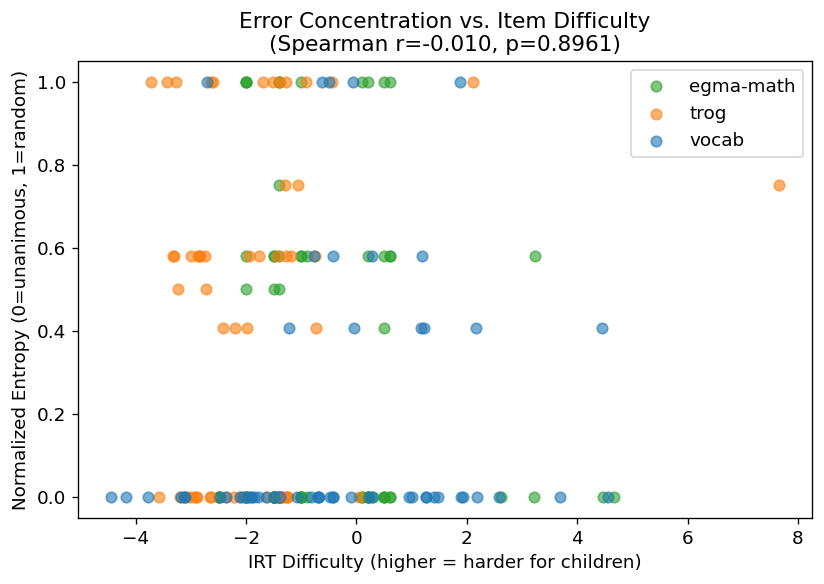

In [13]:
irt_data = raw[raw['irt_difficulty'].notna()][['item_uid', 'irt_difficulty']].drop_duplicates('item_uid')
entropy_irt = entropy_df.merge(irt_data, on='item_uid', how='inner')

if len(entropy_irt) > 10:
    r, p = stats.spearmanr(entropy_irt['normalized_entropy'], entropy_irt['irt_difficulty'])
    print(f'Correlation between error concentration and IRT difficulty:')
    print(f'  Spearman r = {r:.3f}, p = {p:.4f} (n={len(entropy_irt)})')
    print(f'  Interpretation: error concentration is {"independent of" if p > 0.05 else "correlated with"} item difficulty')

    fig, ax = plt.subplots(figsize=(7, 5))
    colors_map = {'vocab': 'C0', 'trog': 'C1', 'egma-math': 'C2', 'mental-rotation': 'C3',
                  'matrix-reasoning': 'C4', 'theory-of-mind': 'C5'}
    for task in sorted(entropy_irt['task'].unique()):
        t = entropy_irt[entropy_irt['task'] == task]
        ax.scatter(t['irt_difficulty'], t['normalized_entropy'],
                  label=task, alpha=0.6, s=40, color=colors_map.get(task, 'gray'))

    ax.set_xlabel('IRT Difficulty (higher = harder for children)')
    ax.set_ylabel('Normalized Entropy (0=unanimous, 1=random)')
    ax.set_title(f'Error Concentration vs. Item Difficulty\n(Spearman r={r:.3f}, p={p:.4f})')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'Only {len(entropy_irt)} items with both entropy and IRT data')

## 7. Model Size vs. Distractor Agreement

Do larger models, when wrong, agree more with each other?

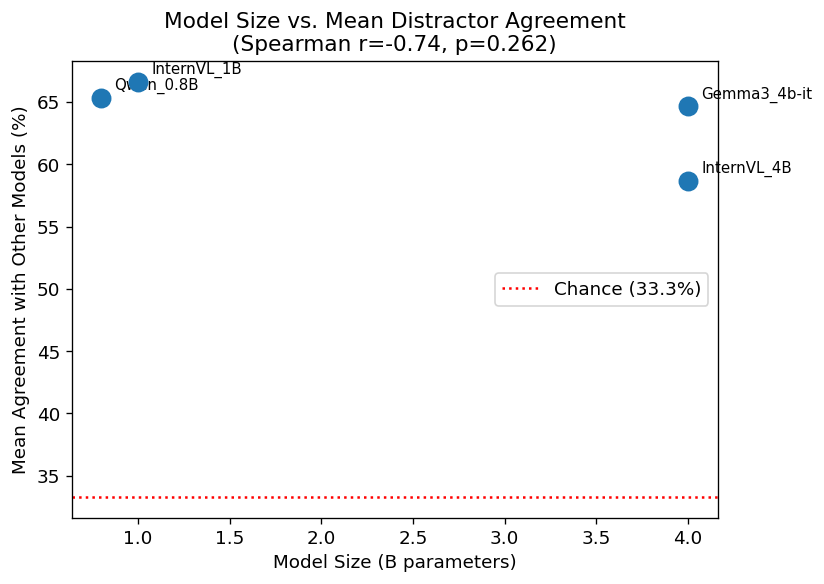

In [14]:
model_sizes = {'qwen35_0.8B': 0.8, 'internvl35_1B': 1.0, 'internvl35_4B': 4.0, 'gemma3_4b-it': 4.0}

model_agr_avg = {}
for m in models:
    others_agr = []
    for _, row in agreement_df.iterrows():
        if row['Model A'] == m or row['Model B'] == m:
            others_agr.append(row['Agreement %'])
    model_agr_avg[m] = np.mean(others_agr) if others_agr else 0

fig, ax = plt.subplots(figsize=(7, 5))
sizes = [model_sizes.get(m, 1) for m in models]
agrs = [model_agr_avg[m] for m in models]
short_names = [m.replace('internvl35', 'InternVL').replace('qwen35', 'Qwen').replace('gemma3', 'Gemma3')
               for m in models]

ax.scatter(sizes, agrs, s=120, zorder=5)
for i, name in enumerate(short_names):
    ax.annotate(name, (sizes[i], agrs[i]), textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.axhline(33.3, color='red', ls=':', label='Chance (33.3%)')

if len(sizes) >= 3:
    r, p = stats.spearmanr(sizes, agrs)
    ax.set_title(f'Model Size vs. Mean Distractor Agreement\n(Spearman r={r:.2f}, p={p:.3f})')
else:
    ax.set_title('Model Size vs. Mean Distractor Agreement')

ax.set_xlabel('Model Size (B parameters)')
ax.set_ylabel('Mean Agreement with Other Models (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Systematic Confusion Patterns

The most common correct-to-predicted transitions reveal interpretable failure modes.

In [15]:
for task in ['mental-rotation', 'egma-math', 'vocab', 'trog', 'theory-of-mind']:
    task_err = errors[errors['task'] == task]
    if len(task_err) == 0:
        continue

    print(f'\n{task.upper()} ({len(task_err)} errors)')
    print('-' * 50)
    pairs = Counter(zip(task_err['correct_content'], task_err['predicted_content']))
    for (correct, chosen), count in pairs.most_common(8):
        pct = 100 * count / len(task_err)
        print(f'  "{correct}" -> "{chosen}"  ({count}x, {pct:.1f}%)')


MENTAL-ROTATION (118 errors)
--------------------------------------------------
  "Dn-000-silh" -> "Dp-000-silh"  (16x, 13.6%)
  "Dp-000-silh" -> "Dn-000-silh"  (12x, 10.2%)
  "Rn-000-silh" -> "Rp-000-silh"  (12x, 10.2%)
  "Rp-000-silh" -> "Rn-000-silh"  (11x, 9.3%)
  "an11-000" -> "ap11-000"  (8x, 6.8%)
  "bp15-000" -> "bn15-000"  (6x, 5.1%)
  "bn12-000" -> "bp12-000"  (6x, 5.1%)
  "bp14-000" -> "bn14-000"  (4x, 3.4%)

EGMA-MATH (243 errors)
--------------------------------------------------
  "8" -> "9"  (9x, 3.7%)
  "12" -> "13"  (6x, 2.5%)
  "6" -> "4"  (6x, 2.5%)
  "12" -> "11"  (4x, 1.6%)
  "12" -> "10"  (4x, 1.6%)
  "9" -> "11"  (4x, 1.6%)
  "2" -> "1"  (4x, 1.6%)
  "5cars" -> "3cars"  (4x, 1.6%)

VOCAB (202 errors)
--------------------------------------------------
  "arbor" -> "tipi"  (4x, 2.0%)
  "colony" -> "herd"  (4x, 2.0%)
  "dressing" -> "ketchup"  (3x, 1.5%)
  "fetch" -> "jump"  (3x, 1.5%)
  "bandage" -> "stretcher"  (3x, 1.5%)
  "triad" -> "myriad"  (3x, 1.5%)
  "latc

## Paper Table: Distractor Unanimity by Task

| Task | Items with ≥2 errors | Unanimous | Unanimity rate |
|------|---------------------|-----------|----------------|
| Mental Rotation | 31 | 31 | 100.0% |
| Theory of Mind | 20 | 17 | 85.0% |
| Vocabulary | 63 | 45 | 71.4% |
| EGMA-Math | 85 | 54 | 63.5% |
| TROG | 69 | 21 | 30.4% |
| Matrix Reasoning | 57 | 17 | 29.8% |
| **Overall** | **325** | **185** | **56.9%** |

**Cross-model error agreement: 63.8%** (chance = 33.3%)

**Interpretable confusion patterns:**
- **Mental rotation:** mirror-image confusion (Rn↔Rp, Dn↔Dp) — inability to distinguish chirality
- **Theory of mind:** systematic "no"→"yes" swap — default affirmative bias or failure to track belief states
- **TROG:** agent-patient role reversal ("boy chases horse"→"horse chases boy") — lexical sensitivity without syntactic structure
- **Vocabulary:** semantically related pairs ("colony"→"herd", "latch"→"lock")
- **EGMA-Math:** numerically adjacent values ("8"→"9", "12"→"13")

**Error concentration is independent of item difficulty** (Spearman r = −0.01, p = 0.90), indicating distractor attractiveness is a structural property of the items, not an artifact of general difficulty.

## 9. Key Findings

## 9. Key Findings

1. **Cross-model distractor agreement: 63.8%** (chance = 33.3% for 4-option items). Models choose the same wrong answer ~2x more often than chance.

2. **Unanimity: 185/325 (57%)** of multi-error items show UNANIMOUS distractor choice.

3. **Task-specific patterns:**
   - Mental Rotation: 100.0% unanimity
   - Theory of Mind: 85.0% unanimity
   - Vocabulary: 71.4% unanimity
   - EGMA-Math: 63.5% unanimity
   - TROG: 30.4% unanimity
   - Matrix Reasoning: 29.8% unanimity

4. **Interpretable confusions:**
   - Mental rotation: mirror-image confusion (Rn↔Rp, Dn↔Dp) at 100%
   - Theory-of-mind: systematic "no"→"yes" errors
   - TROG: agent-patient role reversal ("boy chases horse"→"horse chases boy")
   - Vocab: semantically related confusions ("colony"→"herd", "latch"→"lock")
   - EGMA-Math: numerically adjacent confusions ("8"→"9", "12"→"13")

5. **Error concentration is INDEPENDENT of IRT difficulty** (r≈ 0, p > 0.05), suggesting distractor attractiveness is a structural property of the items, not an artifact of general difficulty.